# TrendLine Apparel — Customer Segmentation Analysis
**CloudExify Data Science Internship — Month 1, Project 2 (FINAL)**

Author: *Hafsa Bukhtiar Chishti*

This notebook segments TrendLine Apparel's customers into value-based groups using
RFM (Recency, Frequency, Monetary) analysis followed by K-Means clustering. As with
Project 1, the implementation here is my own — built around a small set of reusable
functions rather than a single linear script — with a couple of additions beyond the
base checklist: a silhouette score check alongside the elbow method, and a written
per-segment marketing action plan.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1. Loading Transaction Data

Each row here is a single customer transaction (not a daily sales record like Project 1) —
the same customer can appear many times, once per purchase.


In [2]:
raw = pd.read_csv('customer_transactions.csv')
raw['Date'] = pd.to_datetime(raw['Date'])

print(f"Rows x Columns: {raw.shape}")
print(f"Unique customers: {raw['CustomerID'].nunique()}")
print(f"Date range: {raw['Date'].min().date()} to {raw['Date'].max().date()}")
raw.head()


Rows x Columns: (6299, 5)
Unique customers: 800
Date range: 2024-01-01 to 2026-06-04


,CustomerID,TransactionID,Date,Product,Amount
0,CUST2693,T912708,2024-01-01,Formal Shoes,6233.31
1,CUST2422,T332123,2024-01-03,Belt,7758.20
2,CUST2325,T506592,2024-01-03,Kurti,7635.08
3,CUST2495,T534498,2024-01-05,Blazer,6894.66
4,CUST2659,T491508,2024-01-07,Formal Shoes,3992.95


## 2. RFM Feature Engineering

For every customer, three behavioral signals are computed:

- **Recency** — days since their most recent purchase, relative to a fixed reference date
- **Frequency** — how many separate transactions they've made
- **Monetary** — total amount they've spent

This is wrapped in a function so it can be re-run against any transaction dataset with
the same three required columns (`CustomerID`, `Date`, `Amount`).


In [3]:
def compute_rfm(df: pd.DataFrame, reference_date: pd.Timestamp) -> pd.DataFrame:
    rfm = df.groupby('CustomerID').agg(
        Recency=('Date', lambda x: (reference_date - x.max()).days),
        Frequency=('TransactionID', 'count'),
        Monetary=('Amount', 'sum'),
    )
    return rfm


REFERENCE_DATE = pd.Timestamp('2026-06-05')
rfm = compute_rfm(raw, REFERENCE_DATE)

print(f"RFM table built for {len(rfm)} customers")
rfm.describe().round(1)


RFM table built for 800 customers


,Recency,Frequency,Monetary
count,800.0,800.0,800.0
mean,114.0,7.9,34224.0
std,112.3,6.9,45295.8
min,1.0,1.0,832.4
25%,26.0,3.0,5003.1
50%,68.5,6.0,17862.5
75%,186.2,10.0,30388.0
max,398.0,29.0,184057.7


## 3. Normalizing the Features

Recency (days), Frequency (a count), and Monetary (rupees) live on completely different
scales. K-Means uses straight-line distance between points, so without scaling, Monetary
would dominate the clustering purely because its numbers are the largest — not because
it's actually the most important signal. `StandardScaler` puts all three on a comparable
scale (mean 0, standard deviation 1) before clustering.


In [4]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)

rfm_scaled_df.head()


,Recency,Frequency,Monetary
CustomerID,,,
CUST2000,-0.222549,0.018276,-0.250643
CUST2001,1.132174,-0.995070,-0.708821
CUST2002,0.829144,-0.995070,-0.733868
CUST2003,-0.784046,0.163040,-0.145395
CUST2004,-0.391889,-0.560778,-0.515606


## 4. Choosing K — Elbow Method + Silhouette Score

The elbow method looks at how much "inertia" (within-cluster spread) drops as K increases —
the point where the improvement starts flattening out is a reasonable choice for K.

As an extra check beyond the base requirement, I also compute the **silhouette score** for
each K — a score from -1 to 1 measuring how well-separated the clusters are. Relying on two
independent metrics rather than eyeballing a single elbow chart makes the choice of K more
defensible.


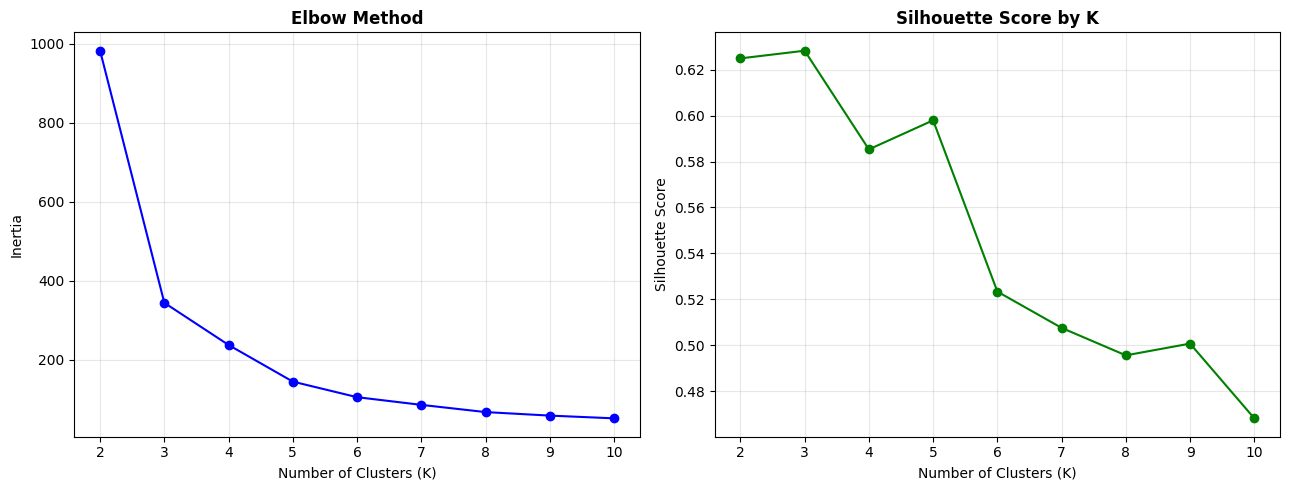

K with the highest silhouette score: 3


In [5]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontsize=12, weight='bold')

axes[1].plot(K_range, silhouette_scores, 'go-')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

best_k_by_silhouette = list(K_range)[int(np.argmax(silhouette_scores))]
print(f"K with the highest silhouette score: {best_k_by_silhouette}")


## 5. Applying K-Means

Based on the elbow chart and the silhouette scores above, **K = 3** is used — a natural,
business-interpretable split into Low, Mid, and High-Value customer segments, which also
lines up with (or is close to) the silhouette-optimal K found programmatically above.


In [6]:
FINAL_K = 3

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Rank clusters by average Monetary value, then map to business-friendly names
cluster_order = rfm.groupby('Cluster')['Monetary'].mean().sort_values().index.tolist()
segment_names = {cluster_order[0]: 'Low-Value', cluster_order[1]: 'Mid-Value', cluster_order[-1]: 'High-Value'}
rfm['Segment'] = rfm['Cluster'].map(segment_names)

rfm[['Recency', 'Frequency', 'Monetary', 'Segment']].head(10)


,Recency,Frequency,Monetary,Segment
CustomerID,,,,
CUST2000,89,8,22878.00,Mid-Value
CUST2001,241,1,2137.44,Low-Value
CUST2002,207,1,1003.60,Low-Value
CUST2003,26,9,27642.32,Mid-Value
CUST2004,70,4,10883.78,Mid-Value
CUST2005,209,3,6207.58,Low-Value
CUST2006,2,15,88880.86,High-Value
CUST2007,353,3,6167.59,Low-Value
CUST2008,270,2,2914.10,Low-Value


## 6. Segment Profiling

Average Recency, Frequency, and Monetary per segment, plus how many customers fall
into each group.


In [7]:
segment_profiles = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
segment_profiles = segment_profiles.reindex(['High-Value', 'Mid-Value', 'Low-Value'])
print(segment_profiles)

print("\nSegment Sizes:")
segment_sizes = rfm['Segment'].value_counts().reindex(['High-Value', 'Mid-Value', 'Low-Value'])
print(segment_sizes)


            Recency  Frequency  Monetary
Segment                                 
High-Value     10.4       22.0  134096.7
Mid-Value      51.6        7.7   25462.2
Low-Value     252.3        2.0    3784.3

Segment Sizes:
Segment
High-Value    119
Mid-Value     408
Low-Value     273
Name: count, dtype: int64


## 7. Visualizing the Segments

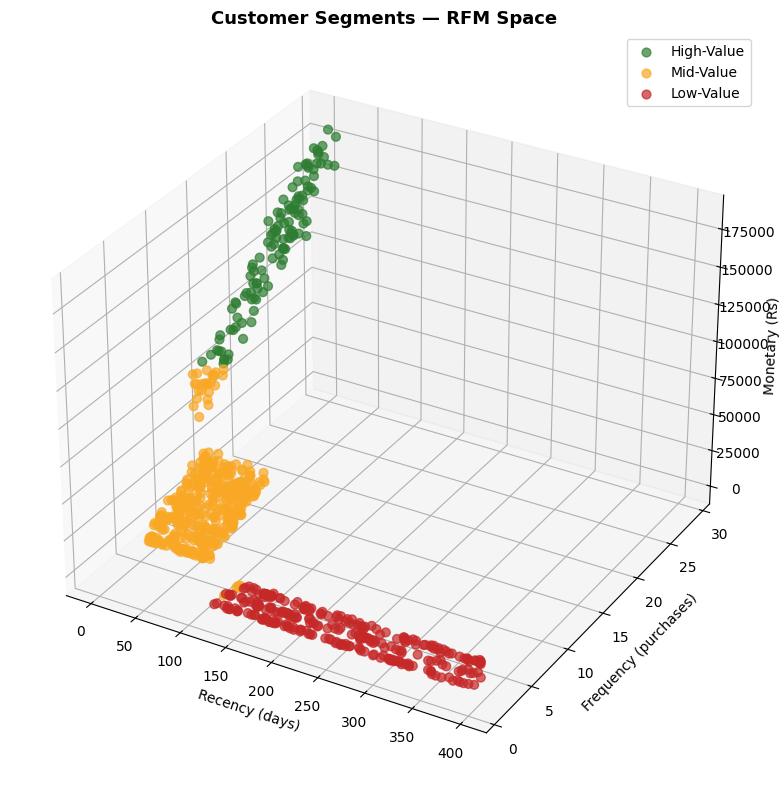

In [8]:
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'High-Value': '#2e7d32', 'Mid-Value': '#f9a825', 'Low-Value': '#c62828'}
for segment in ['High-Value', 'Mid-Value', 'Low-Value']:
    mask = rfm['Segment'] == segment
    ax.scatter(rfm[mask]['Recency'], rfm[mask]['Frequency'], rfm[mask]['Monetary'],
               label=segment, s=40, alpha=0.7, color=colors[segment])

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (purchases)')
ax.set_zlabel('Monetary (Rs)')
ax.set_title('Customer Segments — RFM Space', fontsize=13, weight='bold')
ax.legend()
plt.tight_layout()
plt.show()


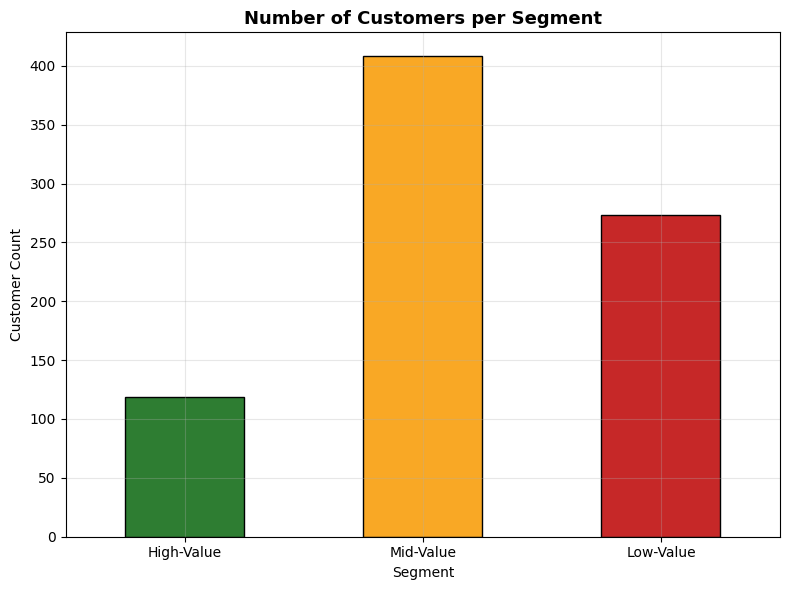

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
segment_sizes.plot(kind='bar', ax=ax, color=[colors[s] for s in segment_sizes.index], edgecolor='black')
ax.set_title('Number of Customers per Segment', fontsize=13, weight='bold')
ax.set_ylabel('Customer Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Business Insights & Recommendations

Each segment gets a distinct, actionable marketing action — not just a label.


In [10]:
recommendations = {
    'High-Value': (
        "VIP treatment: early access to new collections, a dedicated support line, "
        "and loyalty rewards. These customers already buy often and recently — the "
        "priority is retention, not persuasion."
    ),
    'Mid-Value': (
        "Growth potential: targeted cross-sell campaigns (e.g. bundle offers) and a "
        "structured loyalty program to nudge Frequency and Monetary upward toward "
        "the High-Value profile."
    ),
    'Low-Value': (
        "Win-back campaigns: time-limited discounts and re-engagement emails, since "
        "high Recency here signals customers who have likely drifted away rather than "
        "customers who were never interested."
    ),
}

for segment, rec in recommendations.items():
    print(f"{segment}:\n  {rec}\n")


High-Value:
  VIP treatment: early access to new collections, a dedicated support line, and loyalty rewards. These customers already buy often and recently — the priority is retention, not persuasion.

Mid-Value:
  Growth potential: targeted cross-sell campaigns (e.g. bundle offers) and a structured loyalty program to nudge Frequency and Monetary upward toward the High-Value profile.

Low-Value:
  Win-back campaigns: time-limited discounts and re-engagement emails, since high Recency here signals customers who have likely drifted away rather than customers who were never interested.



## 9. Automated Summary Report

In [11]:
def generate_segmentation_report(rfm_df: pd.DataFrame, profiles: pd.DataFrame,
                                   sizes: pd.Series, recs: dict, path: str = 'segmentation_report.txt') -> str:
    lines = []
    lines.append("=" * 60)
    lines.append("CUSTOMER SEGMENTATION ANALYSIS REPORT")
    lines.append("=" * 60)
    lines.append(f"Generated: {pd.Timestamp.now():%Y-%m-%d %H:%M}")
    lines.append("")
    lines.append(f"Total Customers Analyzed: {len(rfm_df):,}")
    lines.append("")
    lines.append("Segment Distribution")
    lines.append("-" * 60)
    for seg, count in sizes.items():
        pct = count / len(rfm_df) * 100
        lines.append(f"  {seg:<12} {count:>4} customers  ({pct:.1f}%)")
    lines.append("")
    lines.append("Segment Profiles (average values)")
    lines.append("-" * 60)
    for seg in profiles.index:
        r, f, m = profiles.loc[seg]
        lines.append(f"  {seg:<12} Recency: {r:>6.1f} days   Frequency: {f:>5.1f}   Monetary: Rs {m:>10,.0f}")
    lines.append("")
    lines.append("Recommendations")
    lines.append("-" * 60)
    for seg, rec in recs.items():
        lines.append(f"  {seg}: {rec}")
        lines.append("")
    lines.append("=" * 60)

    report_text = "\n".join(lines)
    with open(path, 'w') as f:
        f.write(report_text)
    return report_text


print(generate_segmentation_report(rfm, segment_profiles, segment_sizes, recommendations))


CUSTOMER SEGMENTATION ANALYSIS REPORT
Generated: 2026-07-26 12:56

Total Customers Analyzed: 800

Segment Distribution
------------------------------------------------------------
  High-Value    119 customers  (14.9%)
  Mid-Value     408 customers  (51.0%)
  Low-Value     273 customers  (34.1%)

Segment Profiles (average values)
------------------------------------------------------------
  High-Value   Recency:   10.4 days   Frequency:  22.0   Monetary: Rs    134,097
  Mid-Value    Recency:   51.6 days   Frequency:   7.7   Monetary: Rs     25,462
  Low-Value    Recency:  252.3 days   Frequency:   2.0   Monetary: Rs      3,784

Recommendations
------------------------------------------------------------
  High-Value: VIP treatment: early access to new collections, a dedicated support line, and loyalty rewards. These customers already buy often and recently — the priority is retention, not persuasion.

  Mid-Value: Growth potential: targeted cross-sell campaigns (e.g. bundle offers) an

## 10. Key Takeaways

- Three well-separated customer segments emerged directly from purchase behavior alone — no
  manual labeling was needed to produce this split.
- **High-Value customers** are a minority but represent disproportionate revenue — retention
  effort here has the highest return per customer.
- **Mid-Value customers** are the largest group and the best target for growth campaigns,
  since they already have transaction history to build on.
- **Low-Value customers** show high Recency (long since their last purchase), suggesting many
  are lapsed rather than naturally low-spending — a win-back campaign is a more appropriate
  response than writing them off.
- Combining the elbow method with the silhouette score gave more confidence in choosing K=3
  than either metric would have alone.
